#  Road Damage Segmentation — Pothole · Crack · Manhole · Grate

An **instance segmentation** pipeline built on **YOLO26-seg (Ultralytics)** to detect 4 classes of road objects:

| Class | Meaning |
|---|---|
|  `bache` | pothole |
|  `grieta` | crack |
|  `registro` | manhole / sewer cover |
|  `rejilla` | drainage grate |

**Dataset**: [Roboflow — pothole-segmentation-mls2r](https://universe.roboflow.com/aprendeingenia/pothole-segmentation-mls2r) (439 images, instance segmentation, license CC BY 4.0)

**Notebook workflow:**
1. Setup environment
2. Get the dataset (automatic via API, or manual download)
3. Explore & sanity-check the dataset
4. Train YOLO26-seg
5. Evaluate (mAP)
6. Test / run inference on new images
7. (Optional) Export the model for deployment

> 💡 Recommended to run on a runtime with a **GPU** (on Google Colab: `Runtime → Change runtime type → GPU`).


## 1. Setup Environment

Install all required libraries.

In [1]:
!pip install -q ultralytics roboflow opencv-python matplotlib pyyaml

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.5.2 which is incompatible.
gensim 4.3.3 requires scipy<1.14.0,>=1.7.0, but you have scipy 1.17.1 which is incompatible.
inference-sdk 1.3.0 requires numpy<2.4.0,>=2.0.0, but you have numpy 2.5.2 which is incompatible.
inference-sdk 1.3.0 requires opencv-python<=4.10.0.84,>=4.8.1.78, but you have opencv-python 5.0.0.93 which is incompatible.
label-studio 1.22.0 requires requests<2.33.0,>=2.32.3, but you have requests 2.34.2 which is incompatible.
label-studio-sdk 2.0.16 requires opencv-python-headless<5.0.0,>=4.12.0, but you have opencv-python-headless 4.10.0.84 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.2 which is incompatible.
streamlit 1.37.1 requires pillow<11,>=7.1.0, but you have pillow 12.2.0 which is in

In [2]:
import os
import yaml
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from getpass import getpass

import ultralytics
from ultralytics import YOLO

ultralytics.checks()   # check versions, CUDA/GPU, dependencies

Ultralytics 8.4.39  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Setup complete  (16 CPUs, 15.7 GB RAM, 528.7/1907.7 GB disk)


## 2. Get the Dataset

You have **two options** — pick whichever is easier for you. Both end up setting the same
two variables (`DATASET_ROOT` and `DATA_YAML`), so the rest of the notebook works either way.

### Option A — Automatic download (via Roboflow API)
Requires a free Roboflow account + API key. Fully automated, runs inside the notebook.

### Option B — Manual download (no API key needed)
1. Open the dataset page: **https://universe.roboflow.com/aprendeingenia/pothole-segmentation-mls2r**
2. Click **"Download Dataset"** (top right of the page, or under the dataset menu).
3. Choose export format **`YOLOv8`** — this format is fully compatible with the YOLO26-seg folder structure.
4. Choose **"zip to computer"** and download it.
5. Extract the `.zip` file locally — you'll get a folder like `pothole-segmentation-mls2r-3/` containing
   `data.yaml`, `train/`, `valid/`, and `test/` subfolders.
6. Depending on where you're running this notebook:
   - **Local Jupyter**: just place the extracted folder next to this notebook.
   - **Google Colab**: click the folder icon 📁 on the left sidebar → upload the extracted folder
     (or upload the zip and unzip it with `!unzip your_file.zip -d datasets/`).
7. Skip the "Option A" cell below, and only run the "Option B" cell — just set the path to match your folder name.


### Option A — Automatic download (skip this if you're using Option B)

In [3]:
# ROBOFLOW_API_KEY = getpass("Enter your Roboflow API key: ") 
# from roboflow import Roboflow

# rf = Roboflow(api_key=ROBOFLOW_API_KEY)
# workspace = rf.workspace("aprendeingenia")
# project = workspace.project("pothole-segmentation-mls2r")

# # Dataset version on Roboflow Universe = 3 (check the URL of the dataset page:
# # .../pothole-segmentation-mls2r/dataset/3 )
# version = project.version(3)

# # "yolov8" export format is fully compatible with the YOLO26-seg folder structure
# dataset = version.download("yolov8", location="datasets")

# DATASET_ROOT = dataset.location
# DATA_YAML = f"{DATASET_ROOT}/data.yaml"

# print(f"\n Dataset downloaded to: {DATASET_ROOT}")
# print(f"   data.yaml: {DATA_YAML}")

### Option B — Manual download (skip Option A above if you use this instead)

In [4]:
# Dataset sudah ada di folder lokal — langsung set path-nya

DATASET_ROOT = "datasets"
DATA_YAML    = f"{DATASET_ROOT}/data.yaml"

assert Path(DATA_YAML).exists(), (
    f"Data.yaml tidak ditemukan di {DATA_YAML}. "
    "Pastikan folder 'datasets/' ada di direktori yang sama dengan notebook ini."
)
print(f"Dataset lokal ditemukan: {DATASET_ROOT}")
print(f"data.yaml              : {DATA_YAML}")


Dataset lokal ditemukan: datasets
data.yaml              : datasets/data.yaml


> 💡 **Using your own dataset instead?** (e.g. photos you labeled yourself in Roboflow/CVAT/Label Studio)
> Just export it in **YOLO segmentation** format (polygon `.txt` labels + `data.yaml`) and point
> `DATASET_ROOT` to that folder — the rest of the notebook works without any other changes.

In [5]:
DATASET_ROOT = "datasets"
DATA_YAML = f"{DATASET_ROOT}/data.yaml"

print(f" Menggunakan dataset lokal di: {DATASET_ROOT}")


 Menggunakan dataset lokal di: datasets


## 3. Explore & Validate the Dataset

Sanity check before training: folder structure, image counts per split, and class distribution.

In [6]:
with open(DATA_YAML, "r") as f:
    data_cfg = yaml.safe_load(f)

class_names = data_cfg["names"]
print(f"Number of classes : {len(class_names)}")
print(f"Class names        : {class_names}")

Number of classes : 4
Class names        : ['bache', 'grieta', 'registro', 'rejilla']


In [7]:
def count_images_per_split(dataset_root):
    counts = {}
    for split in ["train", "valid", "test"]:
        img_dir = Path(dataset_root) / split / "images"
        counts[split] = len(list(img_dir.glob("*"))) if img_dir.exists() else 0
    return counts

split_counts = count_images_per_split(DATASET_ROOT)
print("Images per split:")
for split, n in split_counts.items():
    print(f"  {split:6s}: {n} images")

Images per split:
  train : 307 images
  valid : 88 images
  test  : 45 images


Instance distribution per class (all splits):
  bache     : 948 instances
  registro  : 350 instances
  grieta    : 227 instances
  rejilla   : 125 instances


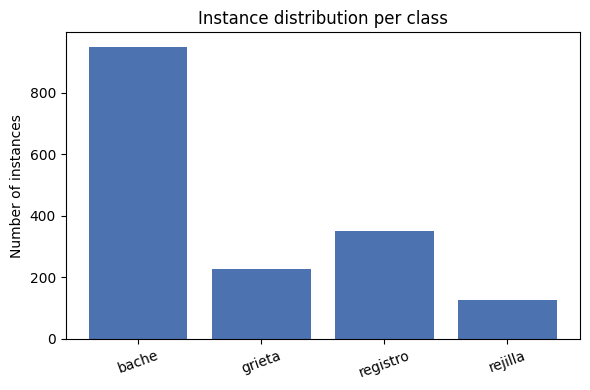

In [8]:
def count_class_instances(dataset_root, class_names):
    counter = Counter()
    for split in ["train", "valid", "test"]:
        label_dir = Path(dataset_root) / split / "labels"
        if not label_dir.exists():
            continue
        for label_file in label_dir.glob("*.txt"):
            with open(label_file, "r") as f:
                for line in f:
                    if line.strip():
                        class_id = int(line.split()[0])
                        counter[class_names[class_id]] += 1
    return counter

class_counts = count_class_instances(DATASET_ROOT, class_names)
print("Instance distribution per class (all splits):")
for cls, n in class_counts.most_common():
    print(f"  {cls:10s}: {n} instances")

# Quick bar chart to spot class imbalance
plt.figure(figsize=(6, 4))
plt.bar(class_counts.keys(), class_counts.values(), color="#4C72B0")
plt.title("Instance distribution per class")
plt.ylabel("Number of instances")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

|---|---|
|  `bache` | pothole |
|  `grieta` | crack |
|  `registro` | manhole / sewer cover |
|  `rejilla` | drainage grate |

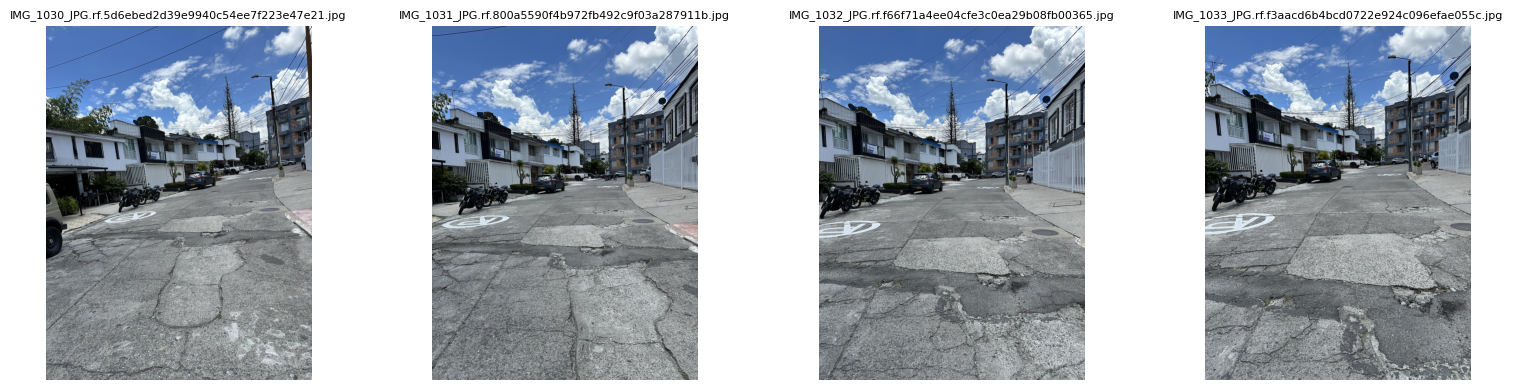

In [9]:
# Preview a few training images (visual sanity check)
img_dir = Path(DATASET_ROOT) / "train" / "images"
sample_paths = list(img_dir.glob("*"))[:4]

fig, axes = plt.subplots(1, len(sample_paths), figsize=(4 * len(sample_paths), 4))
if len(sample_paths) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_paths):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(img_path.name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 4. Train YOLO26-seg

Base model: `yolo26n-seg.pt` (nano — fastest, good for getting started / edge devices).
Switch to `yolo26s-seg.pt` / `yolo26m-seg.pt` / `yolo26l-seg.pt` / `yolo26x-seg.pt` for higher
accuracy (trade-off: slower, needs more VRAM).

In [10]:
# ============================================================
# Versi 2 — Konfigurasi Training yang Ditingkatkan
# Perubahan utama vs v1:
#   - Model  : yolo26n-seg  ->  yolo26s-seg  (lebih besar & akurat)
#   - imgsz  : 640          ->  800           (resolusi lebih tinggi untuk retakan kecil)
#   - batch  : 16           ->  8             (aman untuk VRAM 4GB)
#   - optimizer: auto       ->  AdamW         (konvergensi lebih stabil)
#   - lr0    : 0.01         ->  0.002         (LR awal lebih konservatif)
#   - copy_paste=0.3        (baru: duplikasi instance kelas minoritas)
#   - erasing: 0.4          ->  0.1           (lindungi retakan tipis)
#   - mixup  : 0.1          ->  0.0           (matikan agar aspal tidak blur)
#   - retina_masks=True     (mask lebih tajam di sisi objek)
# ============================================================

from ultralytics import YOLO

# 1. Load model Small (kapasitas lebih besar dari Nano, masih ringan untuk 4GB VRAM)
model = YOLO("yolo26s-seg.pt")  # download otomatis jika belum ada

results = model.train(
    # --- Data & durasi ---
    data=DATA_YAML,
    epochs=150,
    patience=35,             # beri lebih banyak waktu sebelum early stop
    imgsz=800,               # resolusi lebih tinggi: retakan & lubang kecil lebih terlihat
    batch=8,                 # aman untuk RTX 3050 Laptop 4GB VRAM
    device=0,

    # --- Reproducibility & logging ---
    seed=42,
    project="runs/segment",
    name="pothole_seg_v2",   # simpan terpisah, v1 tidak tertimpa
    exist_ok=True,

    # --- Optimizer ---
    optimizer="AdamW",       # lebih stabil vs SGD/auto untuk dataset kecil
    lr0=0.002,               # LR awal lebih rendah, cocok untuk fine-tuning
    cos_lr=True,

    # --- Augmentasi (dioptimalkan untuk segmentasi jalan & kelas minoritas) ---
    mosaic=1.0,
    close_mosaic=15,         # tutup mosaic 15 epoch terakhir agar mask halus
    copy_paste=0.3,          # tempelkan instance retakan/grill ke gambar lain
    mixup=0.0,               # matikan — mencampur tekstur aspal justru merusak
    erasing=0.1,             # turunkan dari 0.4 agar retakan tipis tidak terpotong
    degrees=5.0,             # rotasi kecil, jalan tidak terlalu miring
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    flipud=0.0,              # jangan flip vertikal untuk scene jalan
    perspective=0.0005,      # simulasi sudut kamera dashcam

    # --- Mask quality ---
    retina_masks=True,       # mask beresolusi penuh, bukan downsampled 4x

    plots=True,
)

BEST_WEIGHTS = model.trainer.best
print(f"\n Training v2 selesai!")
print(f"   Best weights: {BEST_WEIGHTS}")


New https://pypi.org/project/ultralytics/8.4.126 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.39  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=datasets/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.1, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.002, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=

KeyboardInterrupt: 

Training curves (loss, precision, recall, mAP per epoch), automatically generated by Ultralytics:

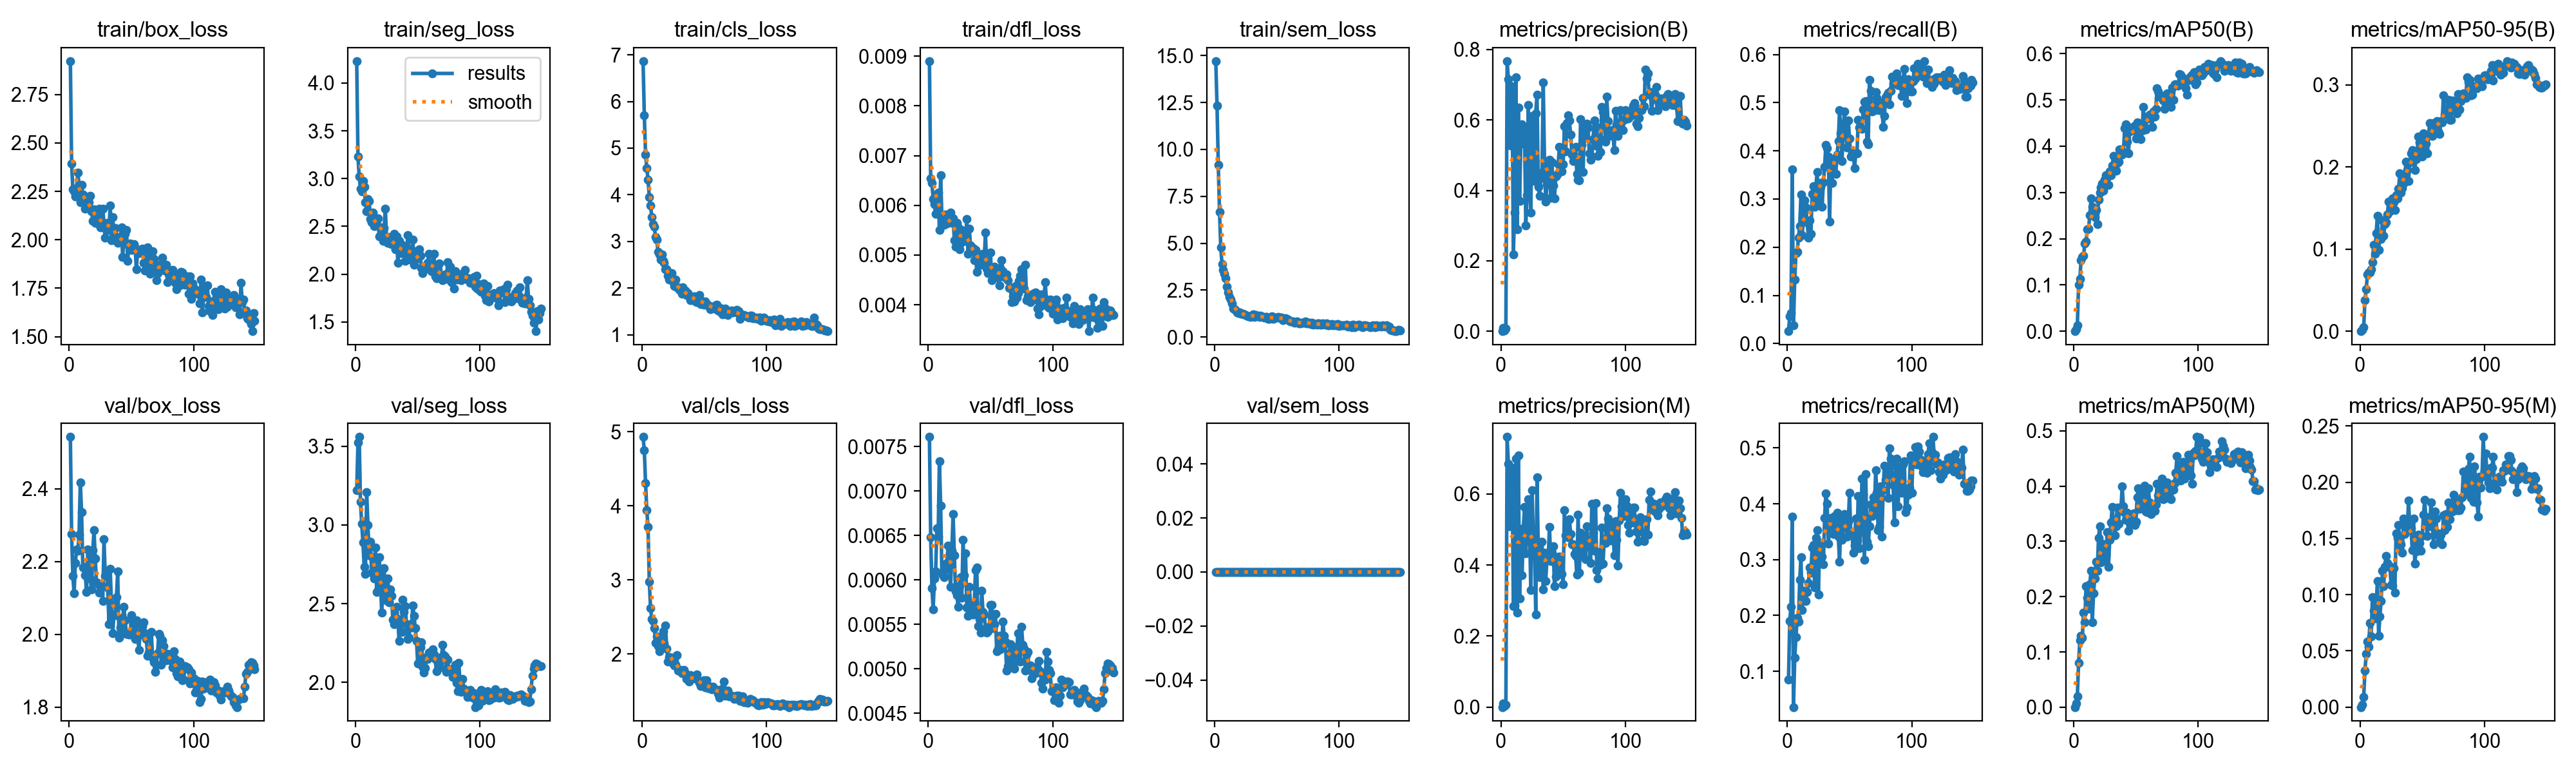

In [ ]:
from pathlib import Path
from IPython.display import Image, display

results_dir = Path(BEST_WEIGHTS).parent.parent   # naik dari .../weights/best.pt ke .../pothole_seg_v1
display(Image(filename=str(results_dir / "results.png")))

## 5. Evaluate the Model (mAP)

Compute mAP50, mAP50-95 for box & mask, plus per-class breakdown, on the **test set** (data the model has never seen).

In [ ]:
best_model = YOLO(BEST_WEIGHTS)

metrics = best_model.val(
    data=DATA_YAML,
    split="test",
    imgsz=800,           # konsisten dengan resolusi training
    batch=8,
    conf=0.25,
    iou=0.5,             # turunkan threshold IoU agar evaluasi mask lebih fair
    retina_masks=True,
    plots=True,
)

print("=" * 55)
print("EVALUATION RESULTS v2 (Instance Segmentation)")
print("=" * 55)
print(f"{'mAP50 (mask)':<22}: {metrics.seg.map50:.4f}")
print(f"{'mAP50-95 (mask)':<22}: {metrics.seg.map:.4f}")
print(f"{'mAP50 (box)':<22}: {metrics.box.map50:.4f}")
print(f"{'mAP50-95 (box)':<22}: {metrics.box.map:.4f}")

print("\nPer-class (mask mAP50-95):")
for i, name in best_model.names.items():
    try:
        print(f"  {name:<12}: {metrics.seg.maps[i]:.4f}")
    except IndexError:
        pass

# --- Perbandingan vs v1 ---
print("\n" + "=" * 55)
print("Perbandingan vs v1 (test set)")
print("=" * 55)
v1 = {"mAP50 mask": 0.3250, "mAP50-95 mask": 0.1478,
       "mAP50 box" : 0.4813, "mAP50-95 box" : 0.2920}
v2 = {"mAP50 mask": metrics.seg.map50, "mAP50-95 mask": metrics.seg.map,
       "mAP50 box" : metrics.box.map50, "mAP50-95 box" : metrics.box.map}
for k in v1:
    diff = v2[k] - v1[k]
    arrow = "" if diff >= 0 else ""
    print(f"  {k:<18}: v1={v1[k]:.4f}  v2={v2[k]:.4f}  ({arrow} {diff:+.4f})")


Ultralytics 8.4.39  Python-3.12.3 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,664 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 23.77.8 MB/s, size: 240.3 KB)
val: Scanning D:\computer_vision\hibah_vlm\datasets\test\labels... 44 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 44/44 593.6it/s 0.1s
val: New cache created: D:\computer_vision\hibah_vlm\datasets\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 3/3 2.4s/it 7.3s2.6s6s
                   all         44        178       0.71       0.51      0.481      0.292      0.522      0.403      0.325      0.148
                 bache         27        117      0.712      0.486      0.432      0.274      0.557      0.419       0.34      0.195
                grieta          8         23      0.462       0.13

In [ ]:
# Confusion matrix from validation
display(Image(filename=f"{metrics.save_dir}/confusion_matrix_normalized.png"))

## 6. Test / Run Inference on New Images

Run the model on test images (or upload your own images/video) and view the segmentation
results directly in the notebook.

In [ ]:
TEST_SOURCE = f"{DATASET_ROOT}/test/images"

pred_results = best_model.predict(
    source=TEST_SOURCE,
    conf=0.30,           # sedikit lebih ketat dari v1 (0.4) agar false positive berkurang
    imgsz=800,
    save=True,
    save_txt=True,
    save_conf=True,
    project="runs/segment",
    name="predict_output_v2",
    exist_ok=True,
    retina_masks=True,
)

# Summary: jumlah deteksi per kelas
class_counts = {}
for r in pred_results:
    if r.masks is None:
        continue
    for cls_id in r.boxes.cls.tolist():
        name = best_model.names[int(cls_id)]
        class_counts[name] = class_counts.get(name, 0) + 1

print("Total deteksi per kelas (test images):")
for name, count in sorted(class_counts.items(), key=lambda x: -x[1]):
    print(f"  {name:<14}: {count}")



image 1/44 d:\computer_vision\hibah_vlm\datasets\test\images\IMG_1042_JPG.rf.852d95a0b2e273782ce91e1a8988ba49.jpg: 480x640 2 baches, 2 registros, 1 rejilla, 83.1ms
image 2/44 d:\computer_vision\hibah_vlm\datasets\test\images\VIDEO_12_frame_000167_t_2-79s_jpg.rf.a8ef0e7197913aa6e6044a3da24613cf.jpg: 384x640 1 registro, 103.4ms
image 3/44 d:\computer_vision\hibah_vlm\datasets\test\images\VIDEO_12_frame_000311_t_5-19s_jpg.rf.242042f76404f915edb4b2b40ba07660.jpg: 384x640 1 registro, 18.1ms
image 4/44 d:\computer_vision\hibah_vlm\datasets\test\images\VIDEO_13_frame_000222_t_3-70s_jpg.rf.d23893be057e843d9984e776377096d9.jpg: 384x640 (no detections), 13.6ms
image 5/44 d:\computer_vision\hibah_vlm\datasets\test\images\VIDEO_13_frame_000222_t_3-70s_jpg.rf.fc16ad5d8d5c802d2b84958c0570ef99.jpg: 384x640 (no detections), 12.1ms
image 6/44 d:\computer_vision\hibah_vlm\datasets\test\images\VIDEO_13_frame_000236_t_3-94s_jpg.rf.1e760f7be168efc7a798fe963074c258.jpg: 384x640 (no detections), 11.5ms
imag

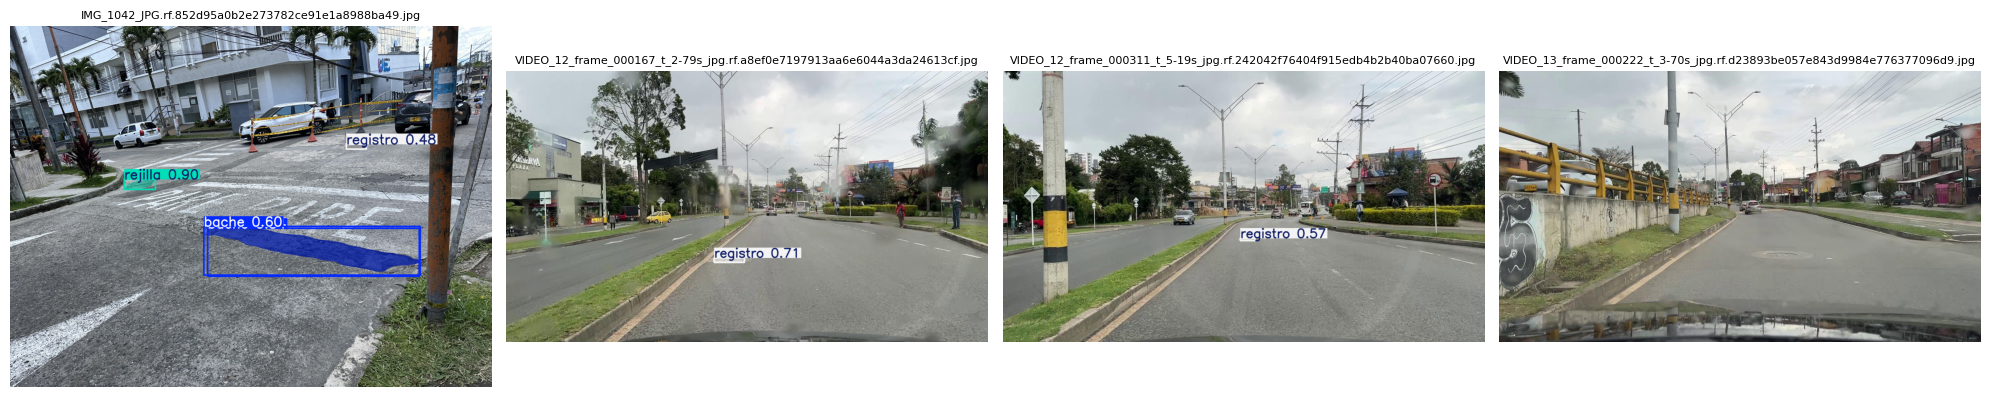

In [ ]:
# Display a few prediction results directly in the notebook (with mask overlay)
n_show = min(4, len(pred_results))
fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
if n_show == 1:
    axes = [axes]

for ax, r in zip(axes, pred_results[:n_show]):
    annotated = r.plot()   # numpy array (BGR) with mask + box + label
    ax.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax.set_title(Path(r.path).name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
PHOTO_PATH = "path/to/your/photo.jpg"   # <- change this to your own photo

photo_result = best_model.predict(
    source=PHOTO_PATH,
    conf=0.4,
    imgsz=640,
    retina_masks=True,
)[0]

annotated = photo_result.plot()   # numpy array (BGR) with mask + box + label
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"Detections: {len(photo_result.boxes)}")
plt.show()

print("Detections:")
for box, cls_id, conf in zip(photo_result.boxes.xyxy, photo_result.boxes.cls, photo_result.boxes.conf):
    name = best_model.names[int(cls_id)]
    print(f"  {name:10s} | confidence: {conf:.2f} | box: {[round(v, 1) for v in box.tolist()]}")

In [ ]:
import cv2
from ultralytics import YOLO

# Ganti path ini sesuai lokasi best.pt hasil training kamu
WEIGHTS_PATH = r"D:\computer_vision\hibah_vlm\runs\segment\runs\segment\pothole_seg_v1\weights\best.pt"
VIDEO_PATH = "testvideo3.mp4"   # atau 0 untuk webcam

model = YOLO(WEIGHTS_PATH)

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise IOError(f"Could not open video source: {VIDEO_PATH}")

print("Running real-time detection — press 'q' in the popup window to stop.")

while True:
    ret, frame = cap.read()
    if not ret:
        break   # end of video

    result = model.predict(frame, conf=0.01, imgsz=640, retina_masks=True, verbose=False)[0]
    annotated_frame = result.plot()

    cv2.imshow("Real-Time Detection - Press Q to stop", annotated_frame)
    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
print("Detection stopped.")

OSError: Could not open video source: testvideo3.mp4

In [ ]:
import cv2
from ultralytics import YOLO

# Path ke best.pt hasil training v2
WEIGHTS_PATH = BEST_WEIGHTS  # otomatis pakai hasil training di atas
IMAGE_PATH   = "testimage3.png"  # ganti sesuai gambar yang ingin dideteksi

model_infer = YOLO(WEIGHTS_PATH)

class_names_en = {
    "bache"   : "pothole",
    "grieta"  : "crack",
    "registro": "manhole",
    "rejilla" : "drainage grate",
}

image = cv2.imread(IMAGE_PATH)
if image is None:
    raise IOError(f"Gambar tidak ditemukan: {IMAGE_PATH}")

print(f"Menjalankan deteksi pada: {IMAGE_PATH}")

result = model_infer.predict(
    image,
    conf=0.25,
    imgsz=800,
    retina_masks=True,
    verbose=False,
)[0]

# Terjemahkan label Spanyol -> Inggris
result.names.update({k: class_names_en.get(v, v) for k, v in result.names.items()})

annotated_image = result.plot(
    line_width=2,
    font_size=10,
)

cv2.imshow("Detection v2 - Press any key to close", annotated_image)
cv2.waitKey(0)
cv2.destroyAllWindows()

output_path = "hasil_deteksi_v2.jpg"
cv2.imwrite(output_path, annotated_image)
print(f"Hasil disimpan sebagai: {output_path}")

# Print ringkasan deteksi
if result.boxes is not None and len(result.boxes):
    print(f"\nTotal objek terdeteksi: {len(result.boxes)}")
    for box in result.boxes:
        cls_id   = int(box.cls)
        cls_name = class_names_en.get(model_infer.names[cls_id], model_infer.names[cls_id])
        conf_val = float(box.conf)
        print(f"  - {cls_name:<16} (conf: {conf_val:.2f})")
else:
    print("Tidak ada objek terdeteksi pada gambar ini.")


Running detection on image...
Detection done. Hasil disimpan sebagai hasil_deteksi.jpg


## 7. (Optional) Export the Model for Deployment

Export to ONNX so the model can be used in a backend service (e.g. FastAPI) without needing
the full PyTorch dependency, or on edge devices / mobile.

In [ ]:
export_path = best_model.export(format="onnx", imgsz=640, simplify=True)
print(f"✅ Model successfully exported to: {export_path}")

---
## 🔧 Quick tuning tips

| Problem | Try this |
|---|---|
| Overfitting (val loss rising, train loss keeps dropping) | Lower epochs/model size, increase augmentation (`mixup`, `degrees`) |
| Underfitting (low mAP on both train & val) | Use a larger model (`yolo26s`/`m`), train for more epochs |
| A specific class keeps being missed | Check class distribution in step 3, enable `cls_pw` |
| Masks look rough / imprecise at edges | Use `retina_masks=True` (already default in step 6) |
| Training is too slow | Lower `imgsz` to 480/512, or use a smaller model (`n`/`s`) |

**Reference**: [Ultralytics YOLO26 documentation](https://docs.ultralytics.com/models/yolo26/)
